# Práctica 8: Forecasting con Regresión Lineal en Series de Tiempo

**Objetivo:** Crear un modelo de regresión lineal para predecir nuevos datos en una serie de tiempo.

**Nuestra Estrategia (Storytelling):**
Sabemos que predecir el comportamiento individual de cada uno de los procesos del sistema usando una simple línea recta no tiene sentido técnico. Sin embargo, la regresión lineal es excelente para otra cosa: **descubrir tendencias históricas**. 

Por ello, hemos decidido transformar nuestro problema. En lugar de mirar cada log individual, vamos a agrupar los datos en una **Serie de Tiempo**. Contaremos cuántos eventos (logs) genera nuestro sistema Linux en intervalos de tiempo regulares (por ejemplo, cada hora). Al hacer esto, podremos ver si la carga sobre el sistema tiende a aumentar o disminuir con el tiempo, y usaremos la regresión lineal para pronosticar cuál será la carga (cantidad de logs) en las próximas horas.

Nuestra serie de tiempo preparada:


,FechaProceso,Log_Count
0,2025-08-23 00:00:00+00:00,1030
1,2025-08-24 00:00:00+00:00,1640
2,2025-08-25 00:00:00+00:00,0
3,2025-08-26 00:00:00+00:00,0
4,2025-08-27 00:00:00+00:00,0


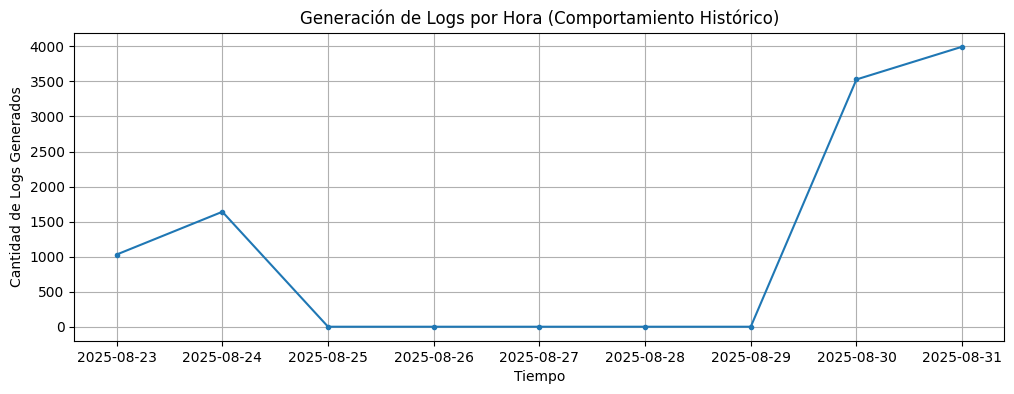

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar el dataset (ajustamos la ruta para apuntar a la Práctica 1)
ruta_csv = '../Practica_1/csv/dataset_linux_journalctl_limpio.csv'
df = pd.read_csv(ruta_csv)

# 2. Convertir la columna de fechas a formato datetime de pandas
# Esto es crucial para poder manipular los datos como una serie de tiempo
df['FechaProceso'] = pd.to_datetime(df['FechaProceso'])

# 3. Ordenar el DataFrame cronológicamente desde el registro más antiguo al más nuevo
df = df.sort_values('FechaProceso')

# 4. Establecer la fecha como el índice del DataFrame (requisito para agrupar temporalmente)
df.set_index('FechaProceso', inplace=True)

# 5. Resample: Agruparemos la información por horas ('h').
# Usamos .size() para contar cuántas filas (logs) ocurrieron en cada hora específica.
df_ts = df.resample('h').size().reset_index(name='Log_Count')

# Mostramos el comienzo de nuestra nueva serie de tiempo y la graficamos rápidamente
print("Nuestra serie de tiempo preparada:")
display(df_ts.head())

# Graficamos el comportamiento histórico
plt.figure(figsize=(12, 4))
plt.plot(df_ts['FechaProceso'], df_ts['Log_Count'], marker='.', linestyle='-')
plt.title('Generación de Logs por Hora (Comportamiento Histórico)')
plt.xlabel('Tiempo')
plt.ylabel('Cantidad de Logs Generados')
plt.grid(True)
plt.show()

## Fase 2: Entrenamiento del Modelo de Tendencia

Para que la regresión lineal nos funcione en este contexto, necesitamos alimentarla con números puros. Por lo tanto, vamos a crear un "índice de tiempo" ($t = 0, 1, 2, ...$) donde cada incremento unitario representa una hora que ha pasado desde el inicio de nuestras mediciones. 

* Nuestra variable independiente ($X$) será este índice de tiempo.
* Nuestra variable dependiente ($y$) será la cantidad de logs (`Log_Count`).

¡Vamos a entrenar el modelo para encontrar la pendiente histórica!

#

In [7]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Crear el índice de tiempo continuo (0, 1, 2, ...)
# Esto nos sirve como nuestra variable "X" numérica para el tiempo transcurrido
df_ts['Time_Index'] = np.arange(len(df_ts))

# 2. Definir 'X' (Variable independiente) e 'y' (Variable dependiente)
X = df_ts[['Time_Index']] # Scikit-learn espera un DataFrame (matriz 2D) para X
y = df_ts['Log_Count']    # Una Serie (1D) para y

# 3. Inicializar y entrenar el modelo de Regresión Lineal
modelo_tendencia = LinearRegression()
modelo_tendencia.fit(X, y)

# 4. Analizar lo que aprendió el modelo (Storytelling)
print("=== RESULTADOS DEL ENTRENAMIENTO ===")
print(f"Intercepción (Cantidad de logs base al inicio): {modelo_tendencia.intercept_:.2f}")
print(f"Pendiente (Cambio de logs por cada hora): {modelo_tendencia.coef_[0]:.2f}\n")

if modelo_tendencia.coef_[0] > 0:
    print("Conclusión: El sistema tiene una tendencia a GENERAR MÁS logs conforme avanza el tiempo.")
else:
    print("Conclusión: El sistema tiene una tendencia a REDUCIR la generación de logs conforme avanza el tiempo.")

=== RESULTADOS DEL ENTRENAMIENTO ===
Intercepción (Cantidad de logs base al inicio): -35.71
Pendiente (Cambio de logs por cada hora): 292.07

Conclusión: El sistema tiene una tendencia a GENERAR MÁS logs conforme avanza el tiempo.


### Fase 3: Forecasting (Inferencia hacia el futuro)

¡Aquí ocurre la magia! Ahora sabemos que, en promedio, nuestro sistema genera **292 logs extra por cada hora que pasa**. Esta es una tendencia de crecimiento muy marcada (la pendiente positiva que encontramos).

Para cumplir con el objetivo de la Práctica 8 ("predict new data"), vamos a:
1. Generar 5 periodos (horas) simuladas hacia el futuro.
2. Pasar esos nuevos tiempos por nuestro modelo para obtener las predicciones.
3. Graficar nuestros datos históricos, la línea de tendencia que aprendió el modelo, y nuestras predicciones futuras.

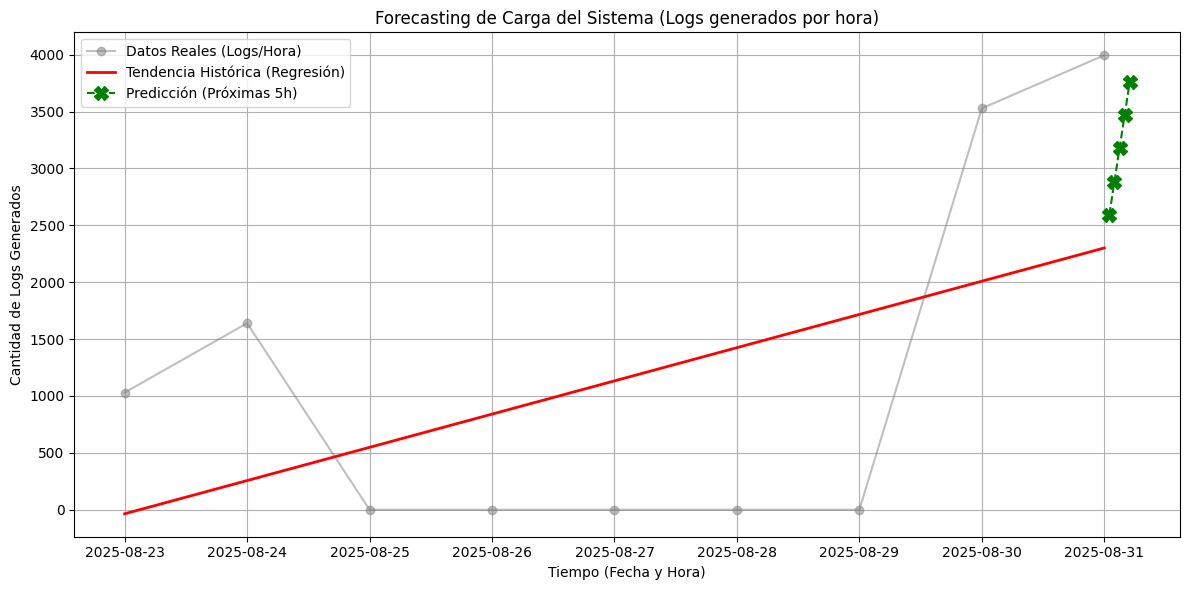

=== FORECASTING: PREDICCIONES PARA LAS PRÓXIMAS 5 HORAS ===
[2025-08-31 01:00] -> Aproximadamente 2592 logs de sistema esperados.
[2025-08-31 02:00] -> Aproximadamente 2884 logs de sistema esperados.
[2025-08-31 03:00] -> Aproximadamente 3177 logs de sistema esperados.
[2025-08-31 04:00] -> Aproximadamente 3469 logs de sistema esperados.
[2025-08-31 05:00] -> Aproximadamente 3761 logs de sistema esperados.


In [8]:
# 1. Definir cuántos periodos hacia el futuro queremos predecir (5 horas)
periodos_futuros = 5
ultimo_indice = df_ts['Time_Index'].max()

# 2. Crear los nuevos índices de tiempo (X futuro: si el último fue 10, crea 11, 12, 13, 14, 15)
X_futuro = pd.DataFrame({'Time_Index': np.arange(ultimo_indice + 1, ultimo_indice + 1 + periodos_futuros)})

# 3. Hacer la predicción con el modelo ya entrenado
predicciones_futuras = modelo_tendencia.predict(X_futuro)

# 4. Crear las fechas reales correspondientes para fines de storytelling/gráfica
ultima_fecha = df_ts['FechaProceso'].max()
fechas_futuras = [ultima_fecha + pd.Timedelta(hours=i) for i in range(1, periodos_futuros + 1)]

# 5. GRAFICAR TODO JUNTO
plt.figure(figsize=(12, 6))

# A. Puntos reales (históricos)
plt.plot(df_ts['FechaProceso'], df_ts['Log_Count'], label='Datos Reales (Logs/Hora)', marker='o', alpha=0.5, color='gray')

# B. Línea de tendencia histórica
tendencia_historica = modelo_tendencia.predict(X)
plt.plot(df_ts['FechaProceso'], tendencia_historica, color='red', linestyle='-', linewidth=2, label='Tendencia Histórica (Regresión)')

# C. Puntos predichos (Forecasting)
plt.plot(fechas_futuras, predicciones_futuras, color='green', marker='X', linestyle='--', markersize=10, label='Predicción (Próximas 5h)')

# Configuración visual de la gráfica
plt.title('Forecasting de Carga del Sistema (Logs generados por hora)')
plt.xlabel('Tiempo (Fecha y Hora)')
plt.ylabel('Cantidad de Logs Generados')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Imprimir los resultados exactos predichos
print("=== FORECASTING: PREDICCIONES PARA LAS PRÓXIMAS 5 HORAS ===")
for f, p in zip(fechas_futuras, predicciones_futuras):
    print(f"[{f.strftime('%Y-%m-%d %H:%M')}] -> Aproximadamente {int(p)} logs de sistema esperados.")

### Conclusión de la Práctica 8

**¿Qué aprendimos con este Forecasting?**

1. **Del Caos a la Tendencia:** Al observar nuestros datos reales (línea gris), notamos un comportamiento altamente irregular y caótico, con picos repentinos de miles de logs y valles donde la actividad cae a cero. Intentar predecir el siguiente "pico" exacto con una regresión lineal simple habría sido un error.
2. **El Poder de la Abstracción Temporal:** Al estructurar nuestros datos como una Serie de Tiempo (agrupando los eventos por intervalos regulares de una hora), pudimos abstraernos del ruido individual de cada proceso.
3. **Tendencia y Predicción:** Nuestro modelo de Regresión Lineal logró aislar la "señal" del "ruido" trazando la línea de tendencia histórica (roja). Con una pendiente positiva de aproximadamente 292 logs por hora, el modelo demostró que, a pesar de los altibajos, **la actividad general y el estrés del servidor van en aumento constante**.
4. **Forecasting Exitoso:** Gracias a esta recta, pudimos inferir el comportamiento proyectado para las siguientes 5 horas (cruces verdes), permitiéndonos anticipar un volumen base de entre 2,500 y 3,700 logs, cumpliendo exitosamente el objetivo de predecir nuevos datos en una serie de tiempo.

**Autor**: Diego Leonardo Alejo Cantú

**Matrícula**: 2013810

**Materia**: Minería de Datos